In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "./stations/" + filename_lo
    filepath_ssc = "./stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [4]:
# read in observational data for each station
data_obs = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")
data_obs = data_obs["obs"]

# ensure datatime format 
data_obs["time"] = pd.to_datetime(data_obs["time"])


In [18]:
station = "SAR003"

# print(data_lo[station])
# print(data_ssc[station])

#print(data_lo[station].data_vars)
print(data_ssc[station].data_vars)

Data variables:
    PAR                           (time_counter, deptht) float32 58kB ...
    turbidity                     (time_counter, deptht) float32 58kB ...
    dissolved_inorganic_carbon    (time_counter, deptht) float32 58kB ...
    total_alkalinity              (time_counter, deptht) float32 58kB ...
    dissolved_oxygen              (time_counter, deptht) float32 58kB ...
    votemper                      (time_counter, deptht) float32 58kB ...
    vosaline                      (time_counter, deptht) float32 58kB ...
    sigma_theta                   (time_counter, deptht) float32 58kB ...
    e3t                           (time_counter, deptht) float32 58kB ...
    nitrate                       (time_counter, deptht) float32 58kB ...
    ammonium                      (time_counter, deptht) float32 58kB ...
    silicon                       (time_counter, deptht) float32 58kB ...
    diatoms                       (time_counter, deptht) float32 58kB ...
    flagellates       

In [ ]:
# print(ds_lo["z_rho"])
# print(ds_ssc["deptht"])

<xarray.DataArray 'deptht' ()> Size: 4B
array(0., dtype=float32)


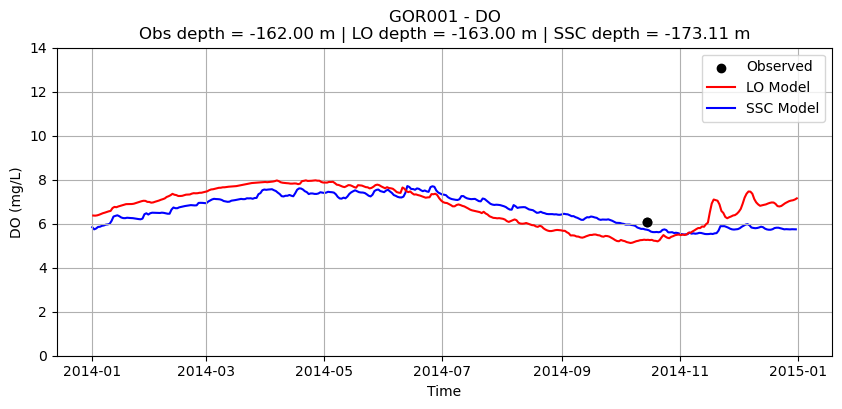

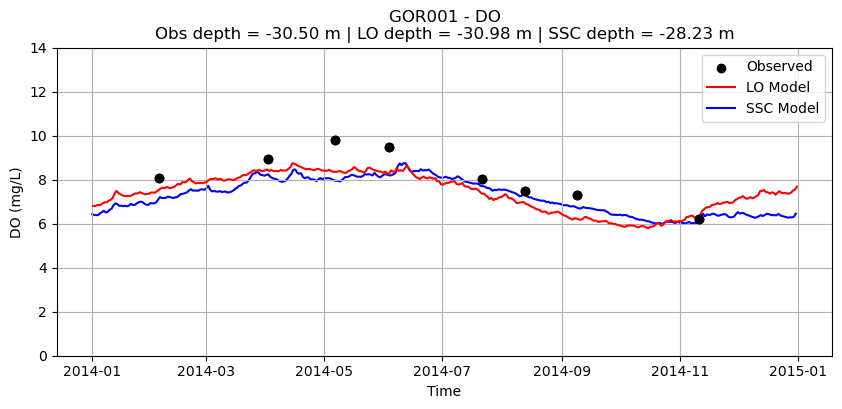

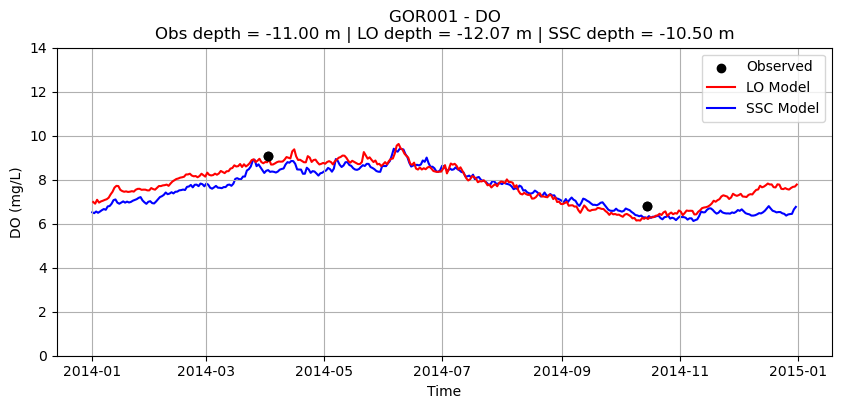

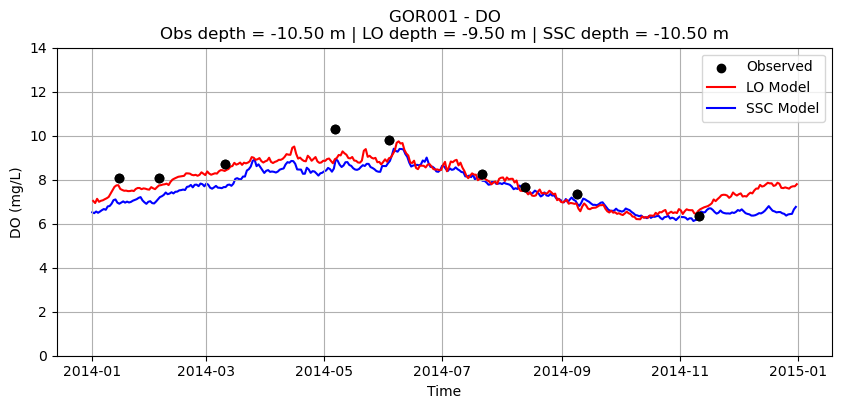

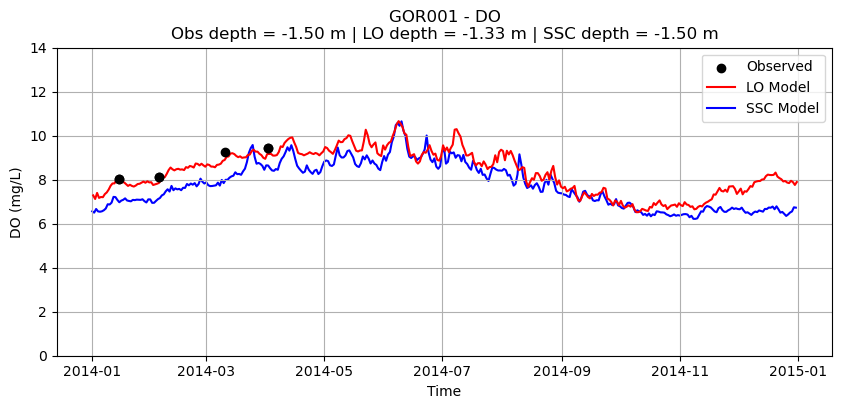

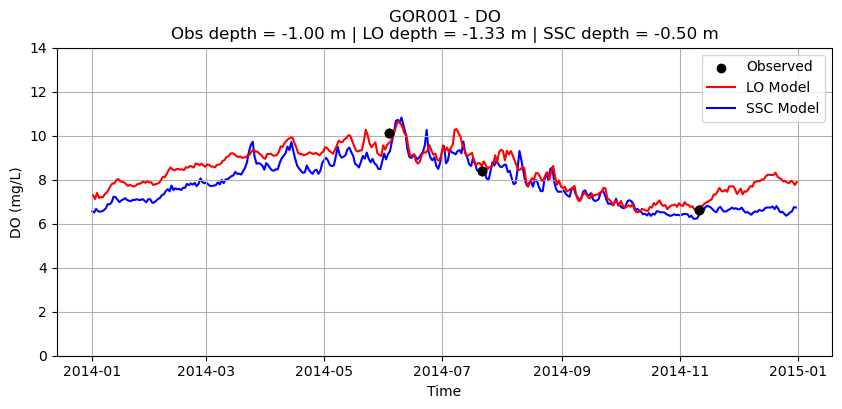

In [10]:
# for DO (conversion to mg/L)

# station
station = "GOR001" # "GOR001" "CSE001" "HCB004" "HCB003" "CMB003" "SIN001" "EAP001" "ADM003" "PSS019" "SKG003" "SAR003"

# variable to plot
varname_ssc = "dissolved_oxygen"
varname_lo = "oxygen"
varname_obs = "DO"

# select station data
ds_lo = data_lo[station]
ds_ssc = data_ssc[station]
ds_obs = data_obs[data_obs["name"] == station]

# unique observed depths
depths = np.sort(ds_obs["z"].dropna().unique())

for obs_depth in depths:
    # select observed data at this depth
    ds_obs_depth = ds_obs[ds_obs["z"] == obs_depth]

    # select model data at this depth
    ssc_depths = -ds_ssc["deptht"].values
    ssc_ind = np.abs(ssc_depths - obs_depth).argmin()
    ssc_model_depth = ssc_depths[ssc_ind]
    ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)
    
    # LO uses sigma coordinates, but depths stored in z_rho
    # LO depth selection
    lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values # z_rho is 2D array, so we take the mean over time to get a 1D array of depths
    lo_ind = np.argmin(np.abs(lo_depths - obs_depth))
    lo_model_depth = lo_depths[lo_ind]
    ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

    # create figure
    plt.figure(figsize=(10, 4))

    # plot observed data
    plt.scatter(ds_obs_depth["time"], ds_obs_depth[varname_obs] *.032, color="black", label="Observed", zorder=3)

    # plot LO model data
    plt.plot(ds_lo_depth["ocean_time"], ds_lo_depth[varname_lo] *0.032, color="red", label="LO Model", zorder=2)

    # plot SSC model data
    plt.plot(ds_ssc_depth["time_counter"], ds_ssc_depth[varname_ssc] *0.032, color="blue", label="SSC Model", zorder=1)

    plt.ylim(0, 14)  # set y-axis limits for better comparison
    
    plt.title(f"{station} - {varname_obs}\n"
              f"Obs depth = {obs_depth:.2f} m | " f"LO depth = {lo_model_depth:.2f} m | " f"SSC depth = {ssc_model_depth:.2f} m")
    
    # add labels and legend
    plt.xlabel("Time")
    plt.ylabel(varname_obs + " (mg/L)")
    plt.legend(loc="upper right")
    plt.grid()
    

    # show plot
    plt.show()

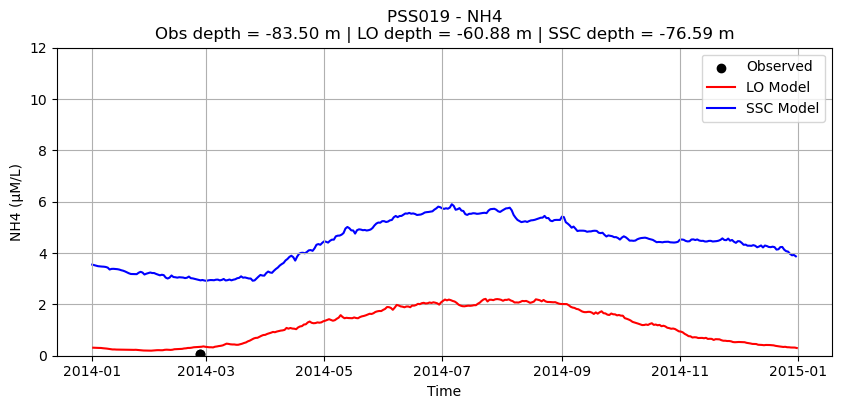

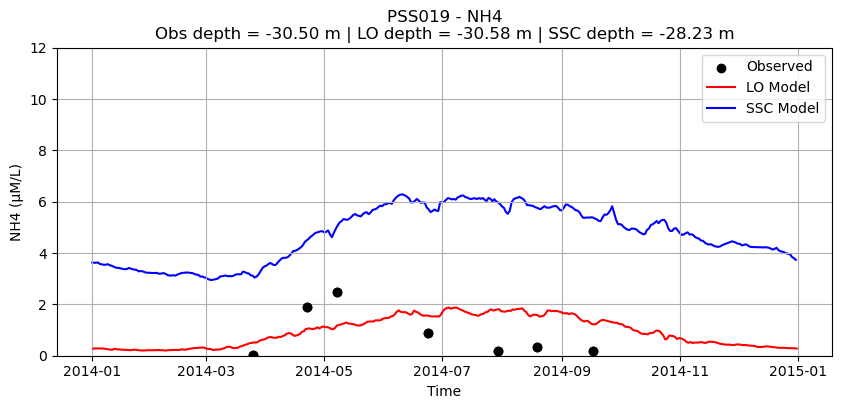

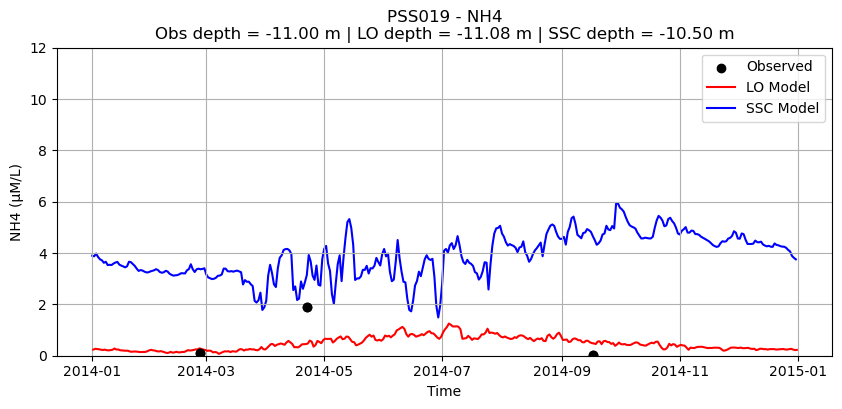

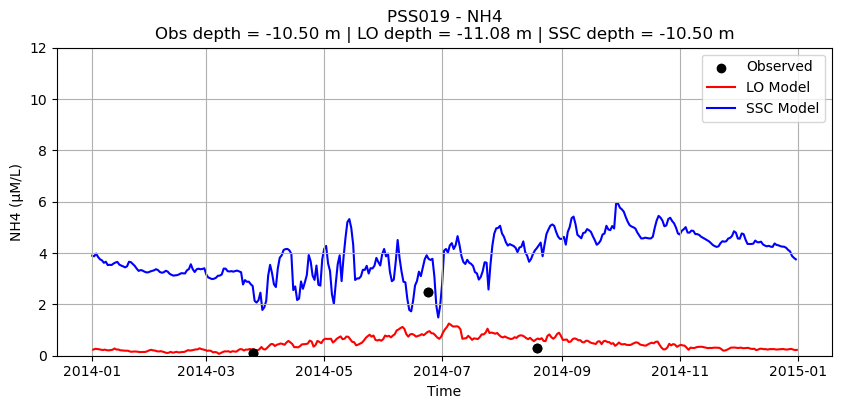

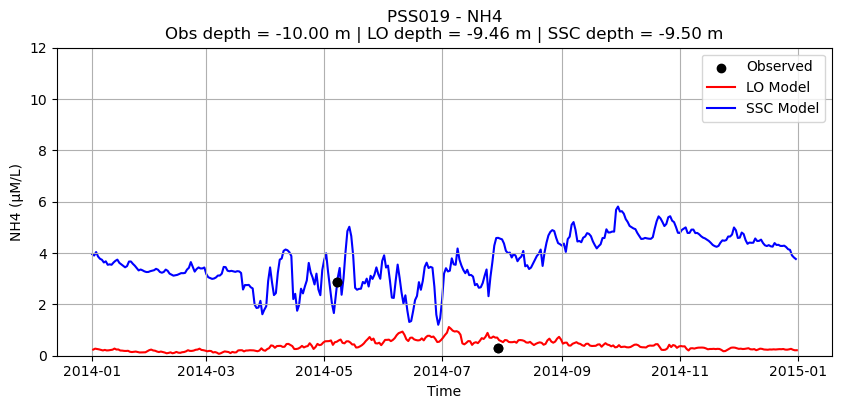

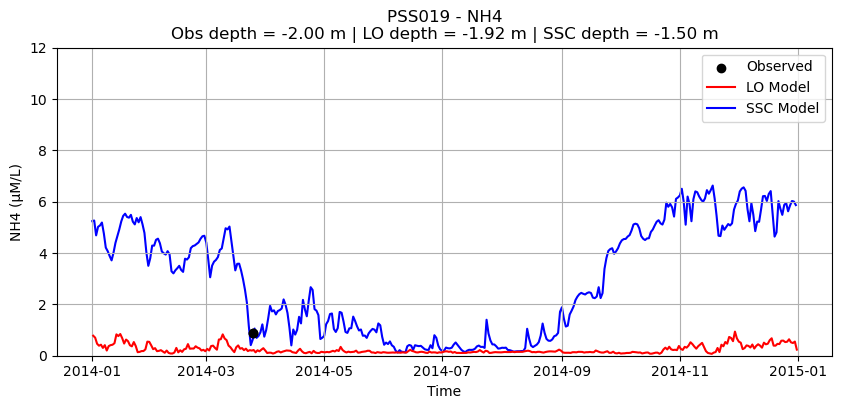

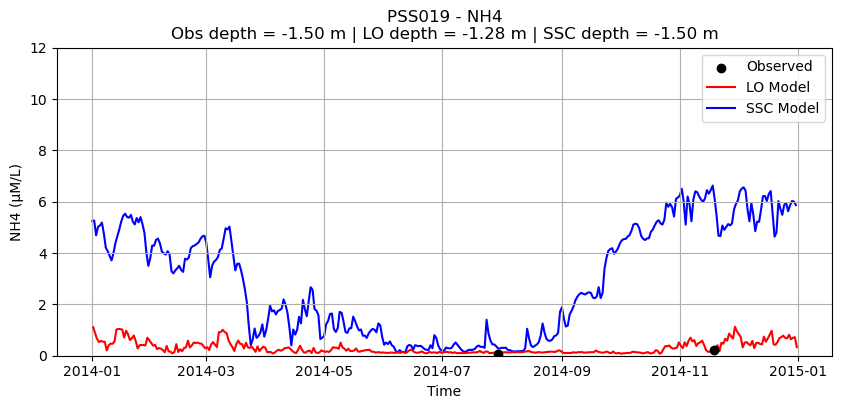

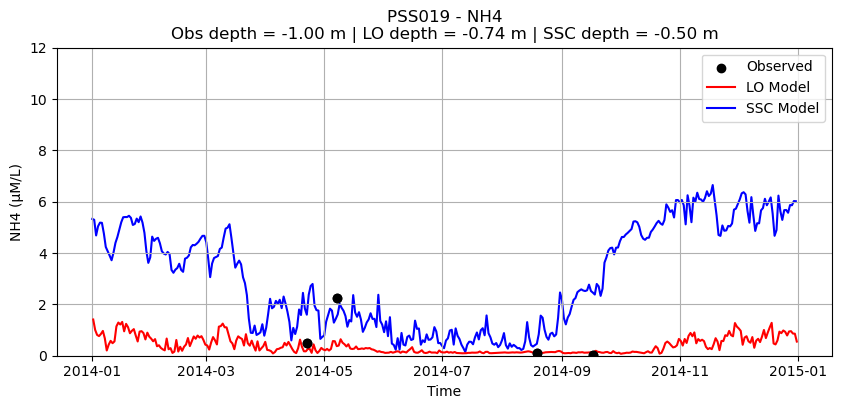

In [22]:
# station
station = "PSS019" # "GOR001" "CSE001" "HCB004" "HCB003" "CMB003" "SIN001" "EAP001" "ADM003" "PSS019" "SKG003" "SAR003"

# variable to plot
# varname_ssc = "nitrate"
# varname_lo = "NO3"
# varname_obs = "NO3"

varname_ssc = "ammonium"
varname_lo = "NH4"
varname_obs = "NH4"

# select station data
ds_lo = data_lo[station]
ds_ssc = data_ssc[station]
ds_obs = data_obs[data_obs["name"] == station]

# unique observed depths
depths = np.sort(ds_obs["z"].dropna().unique())

for obs_depth in depths:
    # select observed data at this depth
    ds_obs_depth = ds_obs[ds_obs["z"] == obs_depth]

    # select model data at this depth
    ssc_depths = -ds_ssc["deptht"].values
    ssc_ind = np.abs(ssc_depths - obs_depth).argmin()
    ssc_model_depth = ssc_depths[ssc_ind]
    ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)
    
    # LO uses sigma coordinates, but depths stored in z_rho
    # LO depth selection
    lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values # z_rho is 2D array, so we take the mean over time to get a 1D array of depths
    lo_ind = np.argmin(np.abs(lo_depths - obs_depth))
    lo_model_depth = lo_depths[lo_ind]
    ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

    # create figure
    plt.figure(figsize=(10, 4))

    # plot observed data
    plt.scatter(ds_obs_depth["time"], ds_obs_depth[varname_obs], color="black", label="Observed", zorder=3)

    # plot LO model data
    plt.plot(ds_lo_depth["ocean_time"], ds_lo_depth[varname_lo], color="red", label="LO Model", zorder=2)

    # plot SSC model data
    plt.plot(ds_ssc_depth["time_counter"], ds_ssc_depth[varname_ssc], color="blue", label="SSC Model", zorder=1)

    # add labels and legend
    plt.title(f"{station} - {varname_obs}\n"
              f"Obs depth = {obs_depth:.2f} m | " f"LO depth = {lo_model_depth:.2f} m | " f"SSC depth = {ssc_model_depth:.2f} m")
    plt.xlabel("Time")
    
    plt.ylabel(varname_obs + " (µM/L)")
    
    # nitrate
    # plt.ylim(0, 35)
    
    # ammonium
    plt.ylim(0, 12)
    
    plt.legend(loc="upper right")
    plt.grid()

    # show plot
    plt.show()